In [1]:
import model as md
import numpy as np
import matplotlib.pyplot as plt
import importlib
import seaborn as sns
importlib.reload(md)


<module 'model' from 'c:\\Users\\celia\\Desktop\\EPFL\\MA2\\Physics_project\\Spike_code\\model.py'>

In [ ]:
#varry: rho, alpha, k1, k1-k2
M=15 #nb of simulation for averaging (precision)
n=500 #size of signal
k1= 5 
k2= 4
alpha = np.sqrt(0.5)

RHO = np.linspace(0,1,20)

M1 =  []
M2 = []
M2bis = []
for rho in RHO:
    over1 = []
    over2 = []
    over2bis = []
    for _ in range(M):
        D, x1, x2 = md.spec(n, k1, k2, rho, alpha) 
        m1, m2 , m2bis= md.overlap(D,x1,x2)
        over1.append(m1)
        over2.append(m2)
        over2bis.append(m2bis)
    M1.append([np.mean(over1), np.std(over1)/np.sqrt(M)])
    M2.append([np.mean(over2),np.std(over2)/np.sqrt(M)])
    M2bis.append([np.mean(over2bis),np.std(over2bis)/np.sqrt(M)])

M1 = np.array(M1)
M2 = np.array(M2)
M2bis = np.array(M2bis)

sns.set_theme(style="whitegrid", context="paper")
plt.errorbar(RHO,M1[:,0], yerr= M1[:,1], label = "x1.v1", capsize=2, linewidth = 1)
plt.errorbar(RHO,M2[:,0],yerr = M2[:,1], label = "x2.v2", capsize=2, linewidth = 1)
plt.errorbar(RHO,M2bis[:,0], yerr= M2bis[:,1], label = "x2.v1", capsize=2, linewidth = 1)
plt.ylabel("Overlaps", fontsize=16)
plt.xlabel(r"Correlation: $\rho$", fontsize=16)
plt.grid(alpha=0.5)
plt.legend(frameon=True, fontsize=16)
plt.tight_layout()
plt.tick_params(axis='both', labelsize=14)
plt.show()


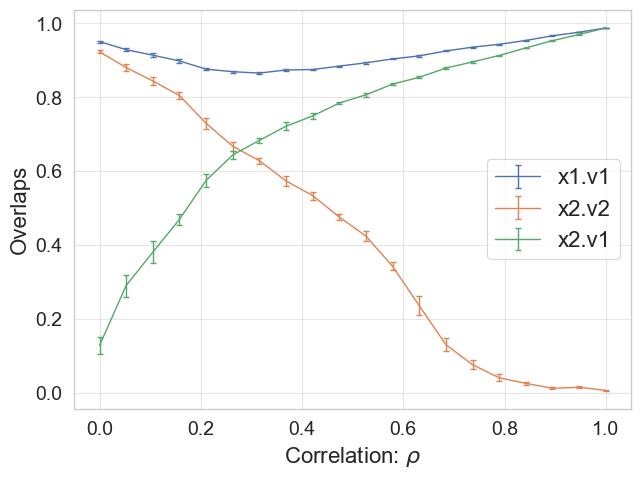

rho 0.0


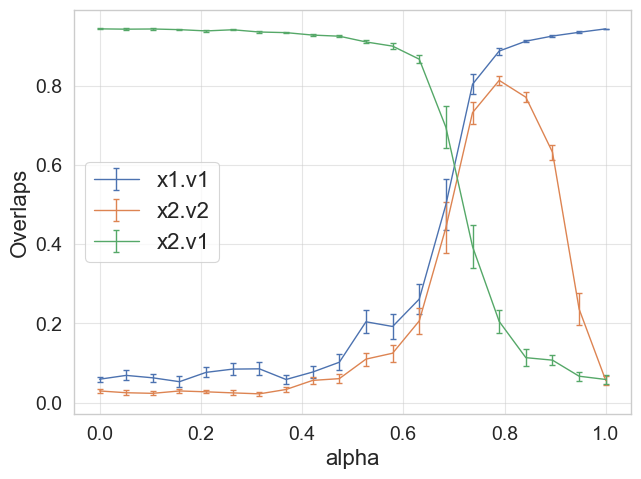

rho 0.2


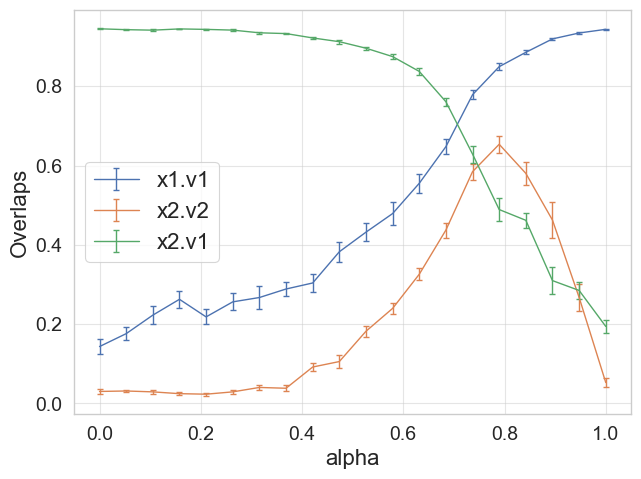

rho 0.4


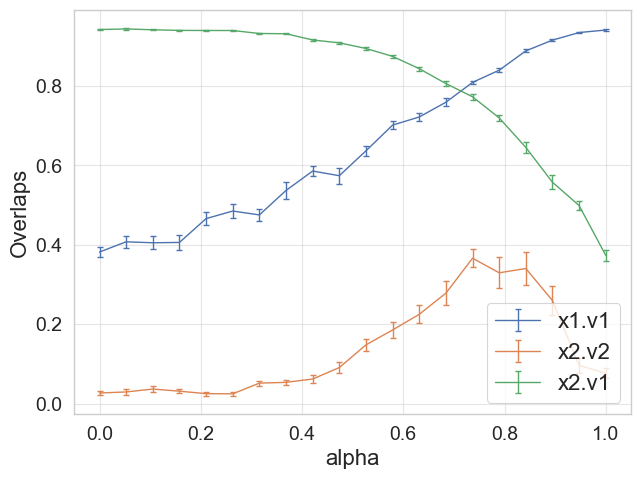

rho 0.6000000000000001


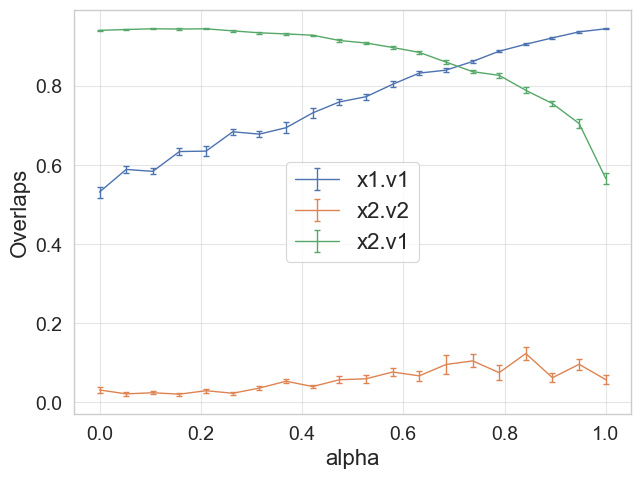

rho 0.8


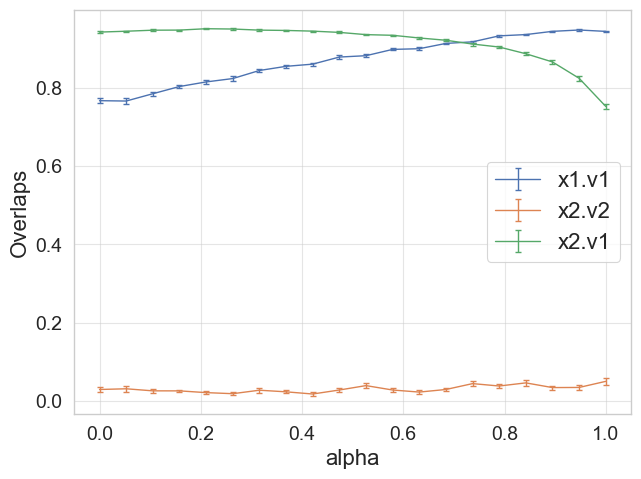

rho 1.0


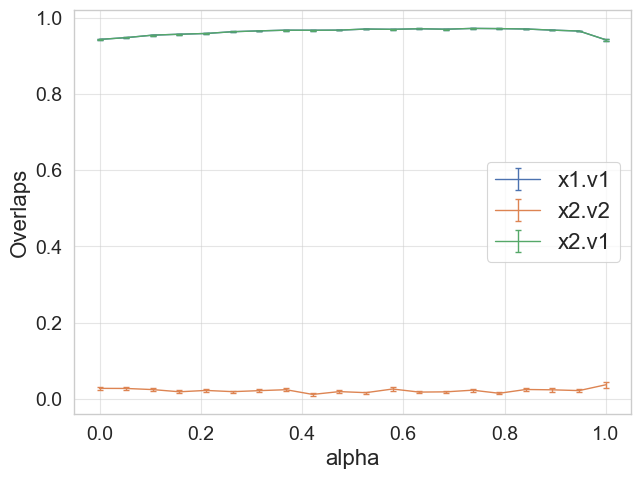

In [125]:
#varry: rho, alpha, k1, k1-k2
M=15 #nb of simulation for averaging (precision)
n=200 #size of signal
k1= 3
k2= 3
alpha = np.sqrt(0.5)

RHO = np.linspace(0,1,6)
K1 = np.linspace(2,7,20)
ALPHA = np.linspace(0,1,20)
for rho in RHO:
    print("rho", rho)
    md.overlap_2spike_varyparam('alpha', ALPHA, M, n, k1, k2, rho, alpha, xlabel=None)

In [113]:
def run_experiment_3D(vary_param_x, vary_values_x, vary_param_y, vary_values_y, 
                       M, n, k1, k2, rho, alpha):
    """
    Parameters:
    -----------
    vary_param_x  : string, parametre sur l'axe x ('rho', 'k1', 'k2', 'alpha', 'n')
    vary_values_x : array, valeurs du parametre x
    vary_param_y  : string, parametre sur l'axe y
    vary_values_y : array, valeurs du parametre y
    M             : int, nombre de simulations
    n, k1, k2, rho, alpha : parametres fixes
    """
    
    Z1 = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z2 = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z2bis = np.zeros((len(vary_values_y), len(vary_values_x)))

    for i, val_y in enumerate(vary_values_y):
        for j, val_x in enumerate(vary_values_x):
            params = {'n': n, 'k1': k1, 'k2': k2, 'rho': rho, 'alpha': alpha}
            params[vary_param_x] = val_x
            params[vary_param_y] = val_y

            over1, over2, over2bis = [], [], []
            for _ in range(M):
                D, x1, x2 = md.spec(params['n'], params['k1'], params['k2'], 
                                      params['rho'], params['alpha'])
                m1, m2, m2bis = md.overlap(D, x1, x2)
                over1.append(m1)
                over2.append(m2)
                over2bis.append(m2bis)

            Z1[i, j] = np.mean(over1)
            Z2[i, j] = np.mean(over2)
            Z2bis[i, j] = np.mean(over2bis)

    # meshgrid pour le plot
    X, Y = np.meshgrid(vary_values_x, vary_values_y)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})
    titles = ['x1.v1', 'x2.v2', 'x2.v1']
    Zs = [Z1, Z2, Z2bis]

    for ax, Z, title in zip(axes, Zs, titles):
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
        ax.set_xlabel(vary_param_x, fontsize=12)
        ax.set_ylabel(vary_param_y, fontsize=12)
        ax.set_zlabel('Overlap', fontsize=12)
        ax.set_title(title, fontsize=14)
        fig.colorbar(surf, ax=ax, shrink=0.5)

    plt.tight_layout()
    plt.show()

    return Z1, Z2, Z2bis

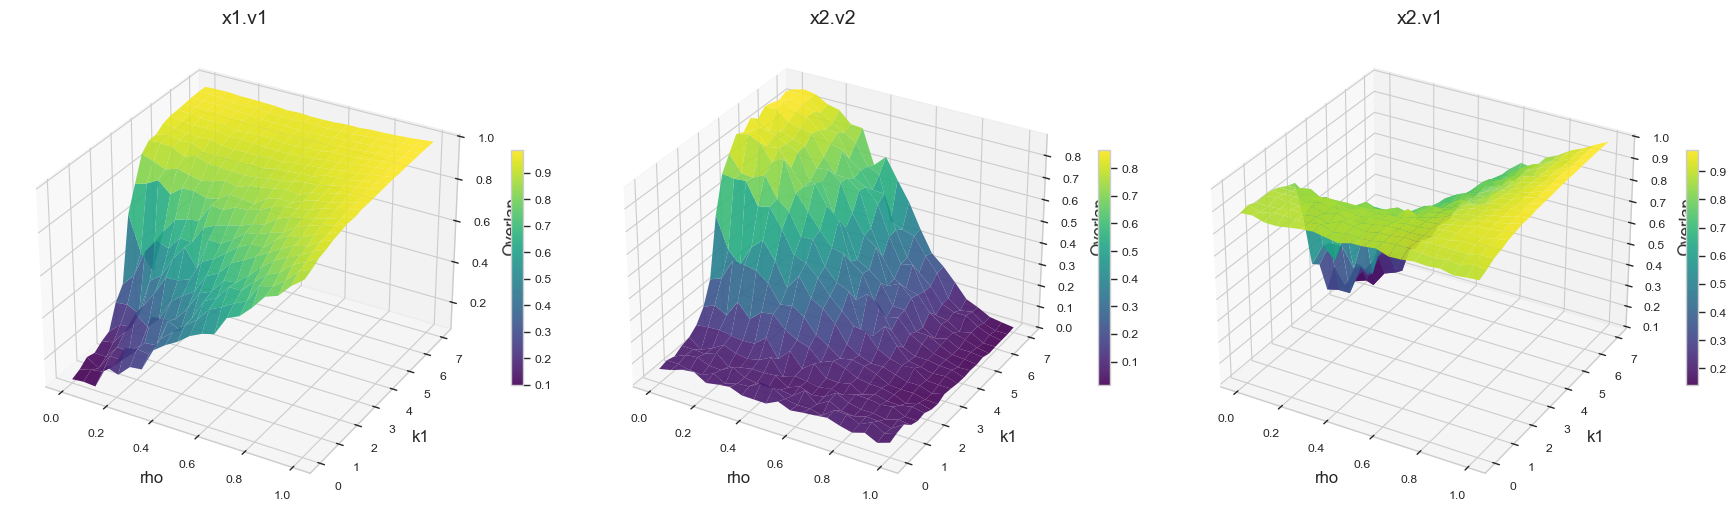

In [116]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 5 
k2= 3
alpha = np.sqrt(0.5)

RHO = np.linspace(0,1,20)
K1 = np.linspace(0,7,20)
ALPHA = np.linspace(0,1,6)

Z1, Z2, Z2bis = run_experiment_3D(
    vary_param_x='rho', vary_values_x=RHO,
    vary_param_y='k1',  vary_values_y=K1,
    M=M, n=n, k1=5, k2=k2, rho=0, alpha=np.sqrt(0.5)
)

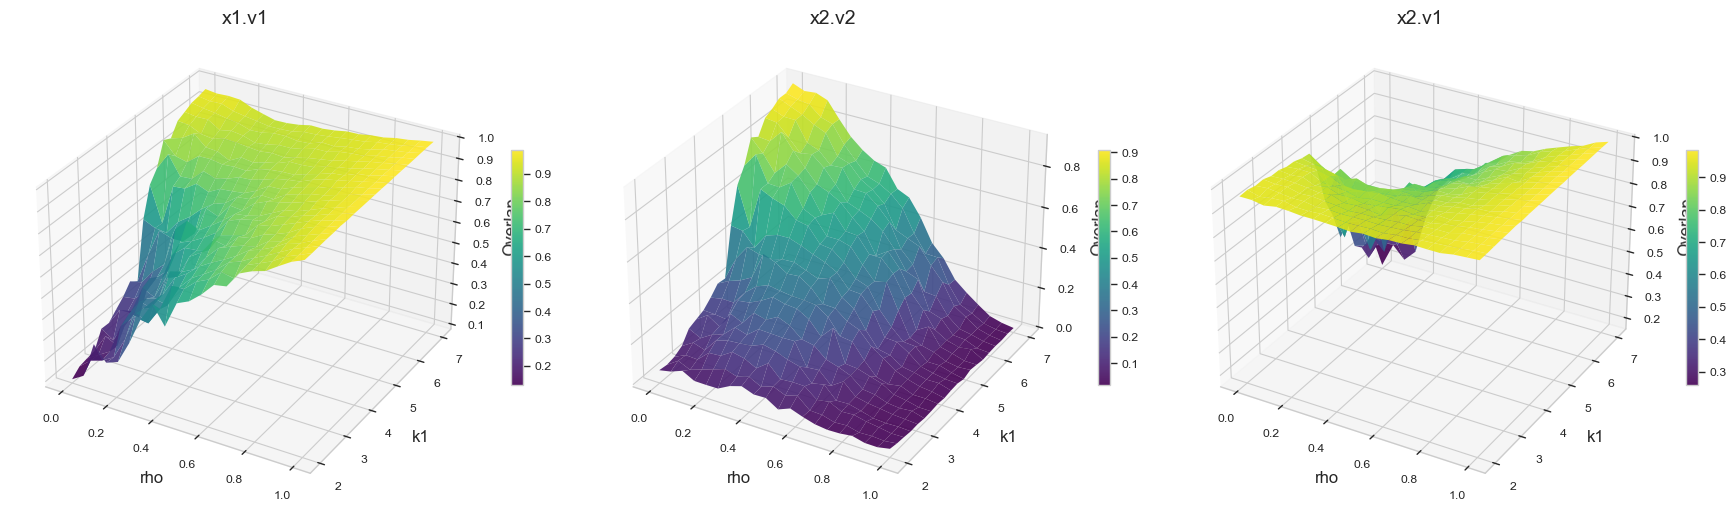

In [115]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 5 
k2= 5
alpha = np.sqrt(0.5)

RHO = np.linspace(0,1,20)
K1 = np.linspace(0,7,20)
ALPHA = np.linspace(0,1,6)

Z1, Z2, Z2bis = run_experiment_3D(
    vary_param_x='rho', vary_values_x=RHO,
    vary_param_y='k1',  vary_values_y=K1,
    M=M, n=n, k1=5, k2=k2, rho=0, alpha=np.sqrt(0.5)
)

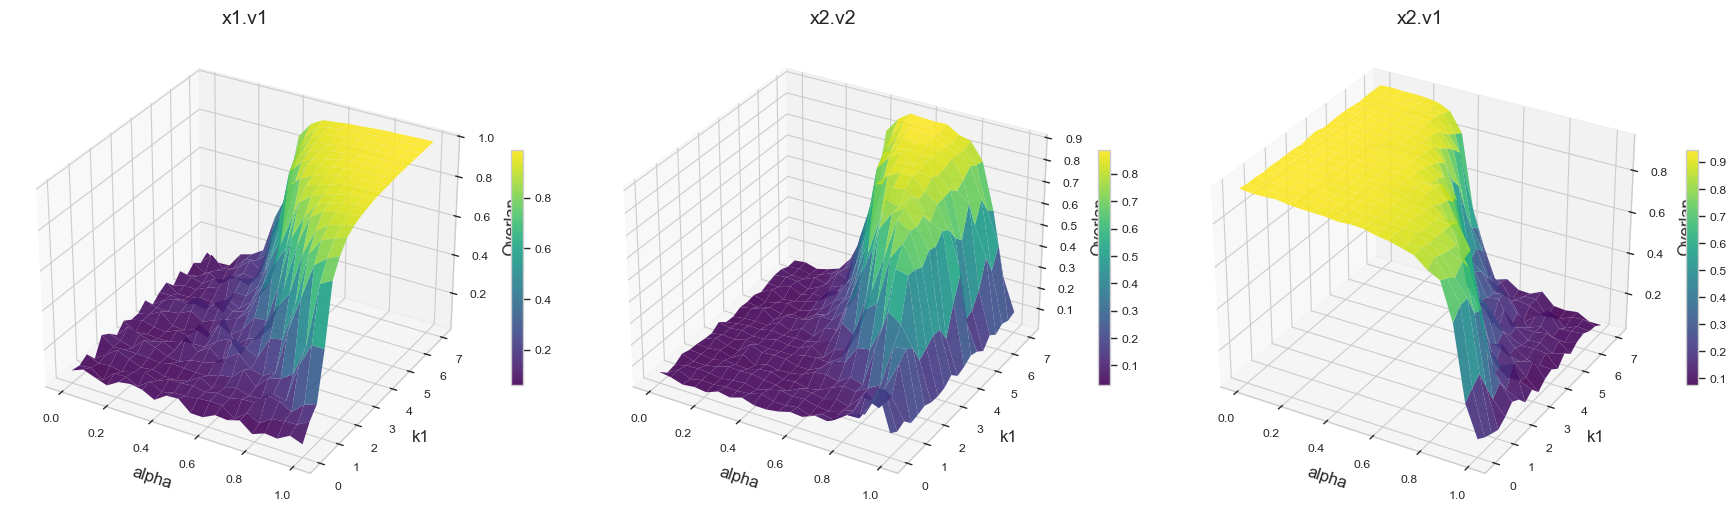

In [121]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 5 
k2= 3
alpha = np.sqrt(0.5)
rho = 0.2
RHO = np.linspace(0,1,20)
K1 = np.linspace(0,7,20)
ALPHA = np.linspace(0,1,20)

Z1, Z2, Z2bis = run_experiment_3D(
    vary_param_x='alpha', vary_values_x=ALPHA,
    vary_param_y='k1',  vary_values_y=K1,
    M=M, n=n, k1=5, k2=k2, rho=0, alpha=np.sqrt(0.5)
)

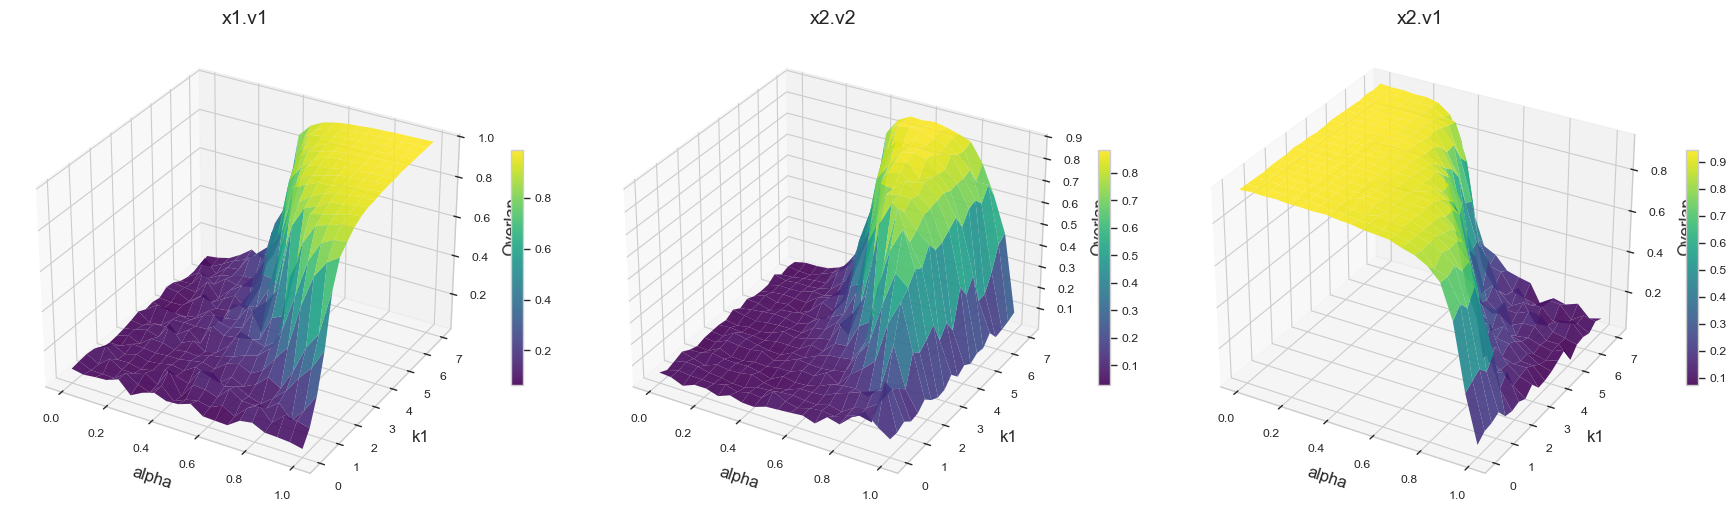

In [122]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 5 
k2= 3
alpha = np.sqrt(0.5)
rho = 0.8
RHO = np.linspace(0,1,20)
K1 = np.linspace(0,7,20)
ALPHA = np.linspace(0,1,20)

Z1, Z2, Z2bis = run_experiment_3D(
    vary_param_x='alpha', vary_values_x=ALPHA,
    vary_param_y='k1',  vary_values_y=K1,
    M=M, n=n, k1=5, k2=k2, rho=0, alpha=np.sqrt(0.5)
)

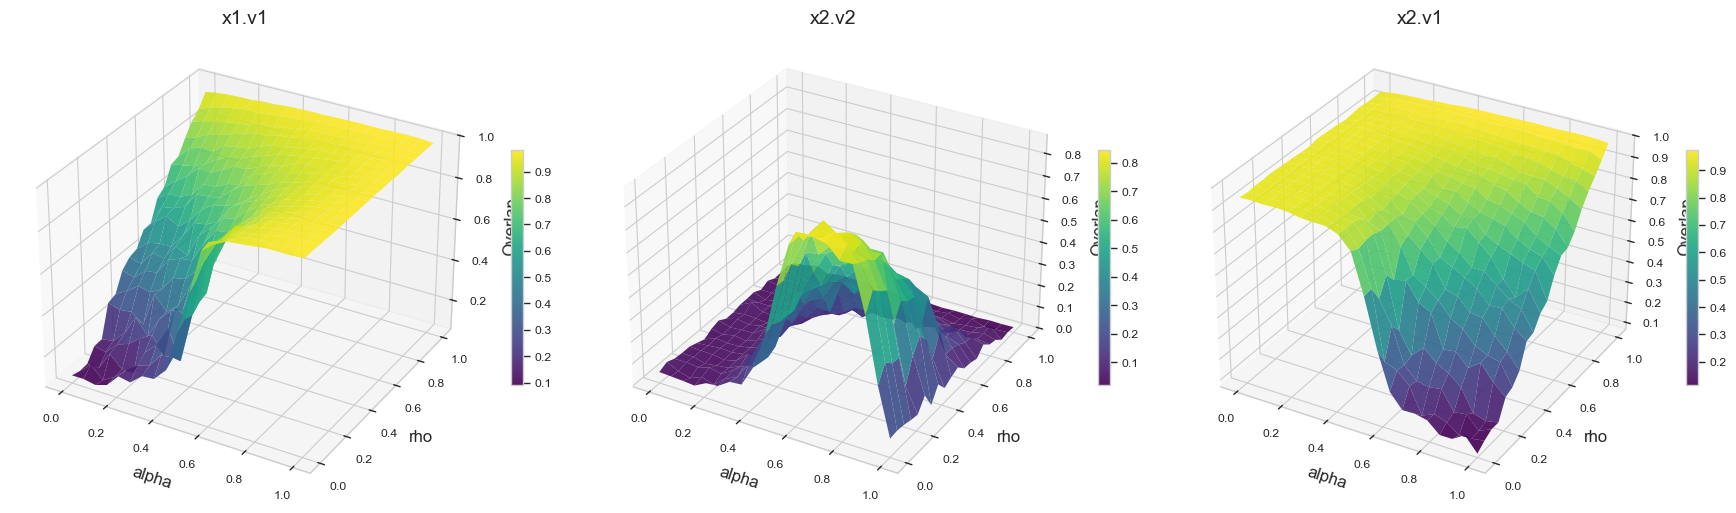

In [124]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 3
k2= 3
alpha = np.sqrt(0.5)
rho = 0.2
RHO = np.linspace(0,1,20)
K1 = np.linspace(0,7,20)
ALPHA = np.linspace(0,1,20)

Z1, Z2, Z2bis = run_experiment_3D(
    vary_param_x='alpha', vary_values_x=ALPHA,
    vary_param_y='rho',  vary_values_y=RHO,
    M=M, n=n, k1=5, k2=k2, rho=0, alpha=np.sqrt(0.5)
)

In [48]:
def run_experiment_2D(vary_param_x, vary_values_x, vary_param_y, vary_values_y, 
                       M, n, k1, k2, rho, alpha):
    
    Z11    = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z22   = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z12 = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z21 = np.zeros((len(vary_values_y), len(vary_values_x)))

    for i, val_y in enumerate(vary_values_y):
        for j, val_x in enumerate(vary_values_x):
            params = {'n': n, 'k1': k1, 'k2': k2, 'rho': rho, 'alpha': alpha}
            params[vary_param_x] = val_x
            params[vary_param_y] = val_y

            over11, over22, over12, over21 = [], [], [], []
            for _ in range(M):
                D, x1, x2 = md.spec(params['n'], params['k1'], params['k2'], 
                                      params['rho'], params['alpha'])
                m11, m22, m12, m21 = md.overlap(D, x1, x2)
                over11.append(m11)
                over22.append(m22)
                over12.append(m12)
                over21.append(m21)

            Z11[i, j]    = np.mean(over11)
            Z22[i, j]    = np.mean(over22)
            Z12[i, j] = np.mean(over12)
            Z21[i, j] = np.mean(over21)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    titles = ['x1.v1', 'x2.v2', 'x1.v2', 'x2.v1']
    Zs = [Z11, Z22, Z12, Z21]

    for ax, Z, title in zip(axes, Zs, titles):
        im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis',
                       extent=[vary_values_x[0], vary_values_x[-1], 
                               vary_values_y[0], vary_values_y[-1]],vmin=0, vmax=1)
        fig.colorbar(im, ax=ax, label='Overlap')
        ax.set_xlabel(vary_param_x, fontsize=12)
        ax.set_ylabel(vary_param_y, fontsize=12)
        ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes = axes.flatten()
    titles = ['max over x1', 'max over x2']
    Zs = [np.maximum(Z11,Z12), np.maximum(Z22,Z21)]

    for ax, Z, title in zip(axes, Zs, titles):
        im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis',
                       extent=[vary_values_x[0], vary_values_x[-1], 
                               vary_values_y[0], vary_values_y[-1]],vmin=0, vmax=1)
        fig.colorbar(im, ax=ax, label='Overlap')
        ax.set_xlabel(vary_param_x, fontsize=12)
        ax.set_ylabel(vary_param_y, fontsize=12)
        ax.set_title(title, fontsize=14)
    # plot f(k1) = sqrt( (k2/k1)^2 / (1 + (k2/k1)^2) )
    #    k1_vals = vary_values_x[vary_values_x > 1]
    #    k2=2
        
    #   f_vals = np.sqrt((k2 / k1_vals)**2 / (1 + (k2 / k1_vals)**2))
    #    ax.plot(k1_vals, f_vals, color='red', linewidth=2, label=r'$f(k_1)$')
    #    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    

    return Z11, Z22, Z12, Z21

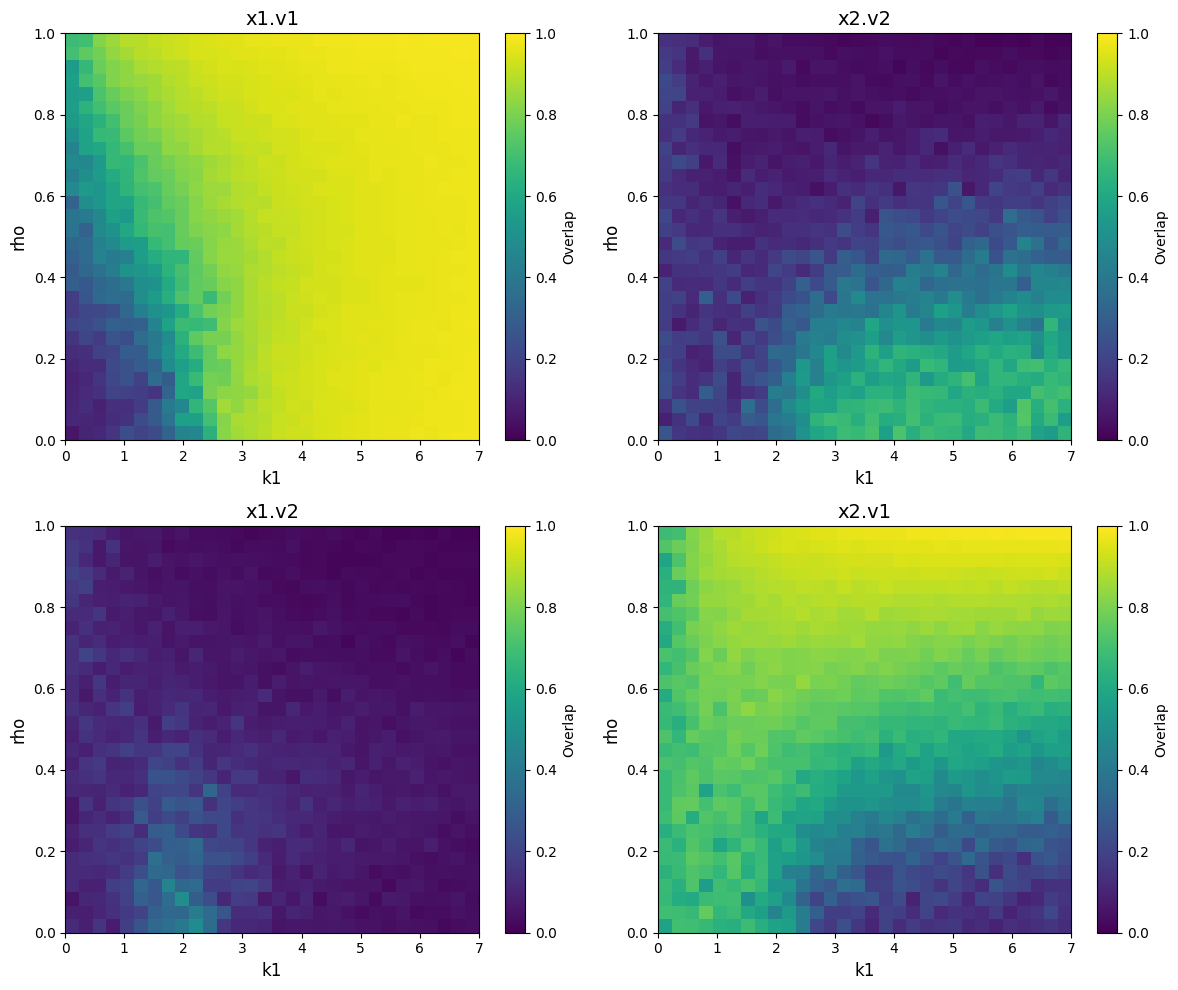

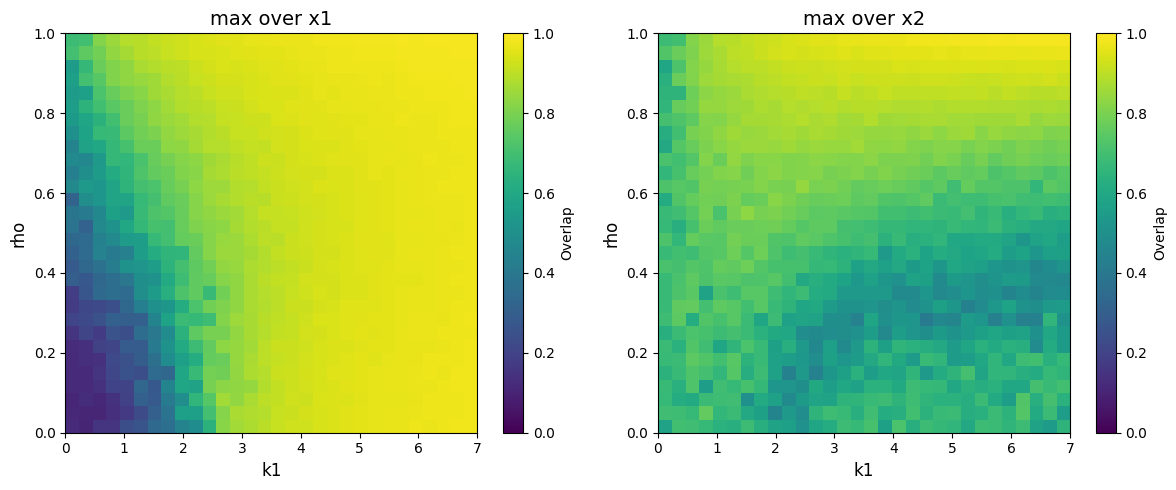

In [51]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 3
k2= 2
alpha = np.sqrt(0.5) #Y1 plus imp que Y2
rho = 0
RHO = np.linspace(0,1,30)
K1 = np.linspace(0,7,30)
ALPHA = np.linspace(0,1,30)

Z11, Z22, Z12, Z21 = run_experiment_2D(
    vary_param_x='k1', vary_values_x=K1,
    vary_param_y='rho',  vary_values_y=RHO,
    M=M, n=n, k1=k1, k2=k2, rho=rho, alpha=alpha
)
